In [4]:
import sys; sys.path.append('..')
import numpy as np, pandas as pd
from src.split import holdout_by_policy, group_cv

feat = pd.read_csv('../data/features_all.csv')
print(feat.groupby('batch').size().to_dict())      # 기대: 46 / 39 / 44

B1 = feat[feat.batch == 'batch1'].reset_index(drop=True)
B2 = feat[feat.batch == 'batch2'].reset_index(drop=True)
B3 = feat[feat.batch == 'batch3'].reset_index(drop=True)

FEATS_A = ['dq_var']
FEATS_B = ['dq_var', 'c1', 'chargetime_mean', 'tavg_mean', 'qd_slope']
print('Batch1 결측치:\n', B1[FEATS_B + ['log_life']].isna().sum())
print('정책 수:', B1['policy'].nunique())

cols = FEATS_B + ['log_life']
for name, d in [('Batch1', B1), ('Batch2', B2), ('Batch3', B3)]:
    print(name, '결측 개수:', d[cols].isna().sum().to_dict())

{'batch1': 46, 'batch2': 39, 'batch3': 44}
Batch1 결측치:
 dq_var             0
c1                 0
chargetime_mean    0
tavg_mean          0
qd_slope           0
log_life           0
dtype: int64
정책 수: 23
Batch1 결측 개수: {'dq_var': 0, 'c1': 0, 'chargetime_mean': 0, 'tavg_mean': 0, 'qd_slope': 0, 'log_life': 0}
Batch2 결측 개수: {'dq_var': 0, 'c1': 0, 'chargetime_mean': 0, 'tavg_mean': 0, 'qd_slope': 0, 'log_life': 0}
Batch3 결측 개수: {'dq_var': 0, 'c1': 0, 'chargetime_mean': 0, 'tavg_mean': 0, 'qd_slope': 0, 'log_life': 0}


In [2]:
train, valid = holdout_by_policy(B1, test_size=0.2)

print(f'Train {len(train)}셀 / {train.policy.nunique()}정책,  Valid {len(valid)}셀 / {valid.policy.nunique()}정책')
assert set(train.policy).isdisjoint(valid.policy)
print('\n[수명 범위]')
for name, d in [('Train', train), ('Valid', valid), ('Batch2', B2)]:
    print(f'{name:7s} min {d.cycle_life.min():.0f}  median {d.cycle_life.median():.0f}  max {d.cycle_life.max():.0f}')
print('\nValid 정책:', sorted(valid.policy.unique()))

Train 35셀 / 18정책,  Valid 11셀 / 5정책

[수명 범위]
Train   min 534  median 857  max 1227
Valid   min 691  median 860  max 1190
Batch2  min 392  median 472  max 1186

Valid 정책: ['3.6C(80%)-3.6C', '5.4C(60%)-3C', '5.4C(70%)-3C', '6C(50%)-3C', '7C(30%)-3.6C']


In [3]:
cv = group_cv(5)
for k, (tr, va) in enumerate(cv.split(train, groups=train['policy'])):
    gtr, gva = train.iloc[tr], train.iloc[va]
    assert set(gtr.policy).isdisjoint(gva.policy)
    print(f'fold{k}: train {len(gtr)}셀 / valid {len(gva)}셀 ({gva.policy.nunique()}정책)')

fold0: train 27셀 / valid 8셀 (4정책)
fold1: train 27셀 / valid 8셀 (4정책)
fold2: train 28셀 / valid 7셀 (4정책)
fold3: train 29셀 / valid 6셀 (3정책)
fold4: train 29셀 / valid 6셀 (3정책)


In [5]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from src.evaluate import cv_evaluate, fit_eval

cv = group_cv(5)
baselines = {
    '평균 예측':        (DummyRegressor(strategy='mean'), FEATS_A),
    'dq_var 선형회귀':  (LinearRegression(),              FEATS_A),
}

rows = []
for name, (model, feats) in baselines.items():
    cv_s, _ = cv_evaluate(model, train, feats, cv)        # Train(CV)
    v_s, _, _ = fit_eval(model, train, valid, feats)      # Valid(Hold-out)
    rows.append({'모델': name,
                 'Train(CV) MAPE': cv_s['MAPE'], 'CV std': cv_s['MAPE_std'],
                 'Valid MAPE': v_s['MAPE'], 'Valid MAE': v_s['MAE'], 'Valid RMSE': v_s['RMSE']})
res_base = pd.DataFrame(rows).round(2)
res_base

,모델,Train(CV) MAPE,CV std,Valid MAPE,Valid MAE,Valid RMSE
0,평균 예측,19.21,8.51,16.08,159.09,207.37
1,dq_var 선형회귀,7.23,2.38,23.57,247.41,370.57


In [6]:
_, m_lin, pred = fit_eval(LinearRegression(), train, valid, FEATS_A)

d = valid[['cell_id', 'policy', 'c1', 'dq_var', 'cycle_life']].copy()
d['pred'] = (10 ** pred).round(0)
d['오차(%)'] = ((d['pred'] - d['cycle_life']) / d['cycle_life'] * 100).round(1)
display(d.reindex(d['오차(%)'].abs().sort_values(ascending=False).index))

print('\n[dq_var 범위]')
print('Train:', train.dq_var.min().round(2), '~', train.dq_var.max().round(2))
print('Valid:', valid.dq_var.min().round(2), '~', valid.dq_var.max().round(2))
print('\n회귀식: log_life = %.3f + (%.3f) * dq_var' % (m_lin.intercept_, m_lin.coef_[0]))

,cell_id,policy,c1,dq_var,cycle_life,pred,오차(%)
1,1,3.6C(80%)-3.6C,3.6,-5.135776,1179.0,1983.0,68.2
0,0,3.6C(80%)-3.6C,3.6,-5.051526,1190.0,1871.0,57.2
2,2,3.6C(80%)-3.6C,3.6,-4.951883,1177.0,1746.0,48.3
4,15,5.4C(60%)-3C,5.4,-4.025168,719.0,918.0,27.7
8,29,6C(50%)-3C,6.0,-3.824633,917.0,798.0,-13.0
6,19,5.4C(70%)-3C,5.4,-3.634370,788.0,700.0,-11.2
9,34,7C(30%)-3.6C,7.0,-3.843104,742.0,809.0,9.0
10,35,7C(30%)-3.6C,7.0,-3.759319,703.0,763.0,8.5
7,28,6C(50%)-3C,6.0,-3.829275,860.0,801.0,-6.9
3,14,5.4C(60%)-3C,5.4,-4.048739,880.0,933.0,6.0



[dq_var 범위]
Train: -4.6 ~ -3.34
Valid: -5.14 ~ -3.63

회귀식: log_life = 1.749 + (-0.301) * dq_var


In [7]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet, Ridge, LinearRegression

cands = [('선형회귀(B)', 'B', {}, make_pipeline(StandardScaler(), LinearRegression()))]
for a in [0.01, 0.1, 1, 10]:
    cands.append(('Ridge(B)', 'B', {'alpha': a}, make_pipeline(StandardScaler(), Ridge(alpha=a))))
for a in [1e-4, 3e-4, 1e-3, 3e-3, 1e-2]:
    for l1 in [0.1, 0.5, 0.9]:
        cands.append(('ElasticNet(B)', 'B', {'alpha': a, 'l1_ratio': l1},
                      make_pipeline(StandardScaler(), ElasticNet(alpha=a, l1_ratio=l1, max_iter=20000))))

rows = []
for name, fs, params, model in cands:
    cv_s, _ = cv_evaluate(model, train, FEATS_B, cv)
    v_s, _, _ = fit_eval(model, train, valid, FEATS_B)
    rows.append({'모델': name, '설정': str(params), 'Train(CV) MAPE': cv_s['MAPE'],
                 'CV std': cv_s['MAPE_std'], 'Valid MAPE': v_s['MAPE']})
res_lin = pd.DataFrame(rows).round(2)

# 모델별로 Train(CV) MAPE가 가장 낮은 설정만 보기
best = res_lin.loc[res_lin.groupby('모델')['Train(CV) MAPE'].idxmin()]
display(best)
display(res_lin.sort_values('Train(CV) MAPE').head(8))

,모델,설정,Train(CV) MAPE,CV std,Valid MAPE
18,ElasticNet(B),"{'alpha': 0.01, 'l1_ratio': 0.5}",7.73,2.36,21.02
4,Ridge(B),{'alpha': 10},8.84,2.44,15.68
0,선형회귀(B),{},9.40,2.09,22.76


,모델,설정,Train(CV) MAPE,CV std,Valid MAPE
18,ElasticNet(B),"{'alpha': 0.01, 'l1_ratio': 0.5}",7.73,2.36,21.02
19,ElasticNet(B),"{'alpha': 0.01, 'l1_ratio': 0.9}",7.88,2.02,19.57
16,ElasticNet(B),"{'alpha': 0.003, 'l1_ratio': 0.9}",8.17,1.99,22.03
15,ElasticNet(B),"{'alpha': 0.003, 'l1_ratio': 0.5}",8.59,1.87,22.28
17,ElasticNet(B),"{'alpha': 0.01, 'l1_ratio': 0.1}",8.84,1.90,22.05
4,Ridge(B),{'alpha': 10},8.84,2.44,15.68
13,ElasticNet(B),"{'alpha': 0.001, 'l1_ratio': 0.9}",8.87,1.86,22.51
12,ElasticNet(B),"{'alpha': 0.001, 'l1_ratio': 0.5}",9.09,1.92,22.60


In [8]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

cands = []
for fs, feats in [('A', FEATS_A), ('B', FEATS_B)]:
    cands.append(('선형회귀', fs, feats, {}, make_pipeline(StandardScaler(), LinearRegression())))
    for a in [1, 10, 30, 100]:
        cands.append(('Ridge', fs, feats, {'alpha': a},
                      make_pipeline(StandardScaler(), Ridge(alpha=a))))
    for a in [0.003, 0.01, 0.03, 0.1]:
        for l1 in [0.1, 0.5, 0.9]:
            cands.append(('ElasticNet', fs, feats, {'alpha': a, 'l1_ratio': l1},
                          make_pipeline(StandardScaler(), ElasticNet(alpha=a, l1_ratio=l1, max_iter=20000))))
    cands.append(('RandomForest', fs, feats, {'depth': 3},
                  RandomForestRegressor(n_estimators=300, max_depth=3, min_samples_leaf=3, random_state=42)))
    cands.append(('GradientBoosting', fs, feats, {'depth': 2},
                  GradientBoostingRegressor(n_estimators=100, max_depth=2, learning_rate=0.05, random_state=42)))

rows = []
for name, fs, feats, params, model in cands:
    cv_s, _ = cv_evaluate(model, train, feats, cv)
    v_s, _, _ = fit_eval(model, train, valid, feats)
    rows.append({'모델': name, 'feature': fs, '설정': str(params),
                 'Train(CV) MAPE': cv_s['MAPE'], 'CV std': cv_s['MAPE_std'], 'Valid MAPE': v_s['MAPE']})
res_all = pd.DataFrame(rows).round(2)

best_all = res_all.loc[res_all.groupby(['모델', 'feature'])['Train(CV) MAPE'].idxmin()]
display(best_all.sort_values('Train(CV) MAPE'))

,모델,feature,설정,Train(CV) MAPE,CV std,Valid MAPE
5,ElasticNet,A,"{'alpha': 0.003, 'l1_ratio': 0.1}",7.23,2.40,23.33
0,선형회귀,A,{},7.23,2.38,23.57
1,Ridge,A,{'alpha': 1},7.30,2.41,22.52
28,ElasticNet,B,"{'alpha': 0.01, 'l1_ratio': 0.5}",7.73,2.36,21.02
21,Ridge,B,{'alpha': 10},8.84,2.44,15.68
18,GradientBoosting,A,{'depth': 2},9.39,1.95,7.81
19,선형회귀,B,{},9.40,2.09,22.76
17,RandomForest,A,{'depth': 3},9.88,4.22,10.67
36,RandomForest,B,{'depth': 3},10.22,5.10,9.19
37,GradientBoosting,B,{'depth': 2},10.73,4.05,7.40


In [9]:
def make_final():
    return make_pipeline(StandardScaler(), ElasticNet(alpha=0.003, l1_ratio=0.1, max_iter=20000))

combos = {
    'dq_var 단독 (현재 모델)':   ['dq_var'],
    '+ c1 (충전 속도)':         ['dq_var', 'c1'],
    '+ chargetime_mean':        ['dq_var', 'chargetime_mean'],
    '+ tavg_mean (평균 온도)':   ['dq_var', 'tavg_mean'],
    '+ qd_slope (용량 기울기)':  ['dq_var', 'qd_slope'],
}

rows = []
for name, feats in combos.items():
    cv_s, _ = cv_evaluate(make_final(), train, feats, cv)
    v_s, _, _ = fit_eval(make_final(), train, valid, feats)
    rows.append({'feature 조합': name, 'Train(CV) MAPE': cv_s['MAPE'],
                 'CV std': cv_s['MAPE_std'], 'Valid MAPE': v_s['MAPE']})
ablation = pd.DataFrame(rows).round(2)
ablation['CV 변화(%p)'] = (ablation['Train(CV) MAPE'] - ablation['Train(CV) MAPE'].iloc[0]).round(2)
display(ablation)

,feature 조합,Train(CV) MAPE,CV std,Valid MAPE,CV 변화(%p)
0,dq_var 단독 (현재 모델),7.23,2.40,23.33,0.00
1,+ c1 (충전 속도),7.31,2.50,23.44,0.08
2,+ chargetime_mean,7.18,2.15,23.16,-0.05
3,+ tavg_mean (평균 온도),7.44,2.27,23.28,0.21
4,+ qd_slope (용량 기울기),8.44,2.23,22.73,1.21


In [10]:
import os
os.makedirs('../results', exist_ok=True)
ablation.to_csv('../results/ablation_features.csv', index=False)
res_all.to_csv('../results/model_comparison_batch1.csv', index=False)
print('saved')

saved


## 최종 모델 확정 (Batch2 평가 이전)
- feature: dq_var (log10 분산), 모델: Elastic Net (alpha=0.003, l1_ratio=0.1), Pipeline(StandardScaler + ElasticNet)
- 선택 기준: Train(CV) MAPE 최저. 차이가 CV std 이내면 더 단순한 모델. Valid는 선택에 사용하지 않음.
- 추가 실험(ablation): 보조 feature(c1, chargetime_mean, tavg_mean, qd_slope)를 하나씩 추가했으나 CV 개선 1%p 미만 → 채택하지 않음.
- Test 평가: Batch1 전체(46셀)로 재학습 후 Batch2 1회 평가. 결과에 따라 모델을 변경하지 않음.

In [12]:
final_feats = FEATS_A
final_model = make_pipeline(StandardScaler(), ElasticNet(alpha=0.003, l1_ratio=0.1, max_iter=20000))

# Train(CV), Valid
cv_s, oof = cv_evaluate(final_model, train, final_feats, cv)
v_s, _, _ = fit_eval(final_model, train, valid, final_feats)

# Test: Batch1 전체(46셀)로 학습 -> Batch2 평가
t_s, m_final, pred_b2 = fit_eval(final_model, B1, B2, final_feats)

TARGET = 9.1   # 논문 MAPE(%)
perf = pd.DataFrame([{
    '모델': 'ElasticNet(dq_var)',
    'Train(CV) MAPE': cv_s['MAPE'], 'Valid MAPE': v_s['MAPE'], 'Test(B2) MAPE': t_s['MAPE'],
    'Gap(Train-Valid)': v_s['MAPE'] - cv_s['MAPE'],
    'Gap(Valid-Test)': t_s['MAPE'] - v_s['MAPE'],
    'Gap(Target-Test)': t_s['MAPE'] - TARGET,
    'Test MAE': t_s['MAE'], 'Test RMSE': t_s['RMSE'],
}]).round(2)
display(perf)

# 참고용 (선택에 사용하지 않음)
ref = []
for nm, mdl in [('평균 예측', DummyRegressor(strategy='mean')),
                ('GradientBoosting(A)', GradientBoostingRegressor(n_estimators=100, max_depth=2,
                                                                  learning_rate=0.05, random_state=42))]:
    s, _, _ = fit_eval(mdl, B1, B2, final_feats)
    ref.append({'모델': nm, 'Test(B2) MAPE': s['MAPE'], 'Test MAE': s['MAE']})
display(pd.DataFrame(ref).round(2))

# 셀별 오차 (오류 분석용)
e = B2[['cell_id', 'policy', 'c1', 'dq_var', 'cycle_life']].copy()
e['pred'] = (10 ** pred_b2).round(0)
e['오차(%)'] = ((e['pred'] - e['cycle_life']) / e['cycle_life'] * 100).round(1)
display(e.reindex(e['오차(%)'].abs().sort_values(ascending=False).index).head(10))

import os; os.makedirs('../results', exist_ok=True)
perf.to_csv('../results/model_performance.csv', index=False)

,모델,Train(CV) MAPE,Valid MAPE,Test(B2) MAPE,Gap(Train-Valid),Gap(Valid-Test),Gap(Target-Test),Test MAE,Test RMSE
0,ElasticNet(dq_var),7.23,23.33,36.67,16.1,13.34,27.57,177.53,189.7


,모델,Test(B2) MAPE,Test MAE
0,평균 예측,67.09,318.37
1,GradientBoosting(A),33.29,164.10


,cell_id,policy,c1,dq_var,cycle_life,pred,오차(%)
6,6,3.6C(9%)-5C,3.6,-3.682411,393.0,739.0,88.0
2,2,5.2C(50%)-4.25C,5.2,-3.606758,424.0,714.0,68.4
15,15,3.6C(9%)-5C,3.6,-3.417112,396.0,654.0,65.2
19,19,6C(60%)-3C,6.0,-3.292164,392.0,617.0,57.4
18,18,5.2C(50%)-4.25C,5.2,-3.582748,449.0,706.0,57.2
21,21,6C(60%)-3C,6.0,-3.332035,408.0,629.0,54.2
27,29,5.2C(58%)-4C,5.2,-3.493028,452.0,677.0,49.8
26,28,4.8C(80%)-4.8C,4.8,-3.414496,437.0,653.0,49.4
0,0,5.2C(58%)-4C,5.2,-3.576617,477.0,704.0,47.6
25,27,5.2C(50%)-4.25C,5.2,-3.558187,474.0,698.0,47.3


In [13]:
from scipy.stats import spearmanr

# 1) Batch2에서 순위는 유지되는가 + 평균 편향
rho, _ = spearmanr(B2['dq_var'], B2['log_life'])
bias = (pred_b2 - B2['log_life']).mean()     # 로그 단위 평균 오차 (+면 과대 예측)
print(f'Batch2: Spearman(dq_var, 수명) = {rho:.3f},  평균 로그 오차 = {bias:+.3f}  (약 {10**bias:.2f}배로 과대 예측)')

# 2) 배치별로 dq_var-수명 직선이 얼마나 다른가
for name, d in [('Batch1', B1), ('Batch2', B2), ('Batch3', B3)]:
    m = LinearRegression().fit(d[['dq_var']], d['log_life'])
    print(f'{name}: log_life = {m.intercept_:.3f} + ({m.coef_[0]:.3f}) * dq_var,  상관 {np.corrcoef(d.dq_var, d.log_life)[0,1]:.3f}')

# 3) Batch3 추가 평가 (모델은 이미 확정, 평가만)
t3, _, pred_b3 = fit_eval(final_model, B1, B3, final_feats)
b3 = pd.DataFrame([{'모델': 'ElasticNet(dq_var)', 'Test(B2) MAPE': t_s['MAPE'], 'Batch3 MAPE': t3['MAPE'],
                    'Gap(Batch2-Batch3)': t3['MAPE'] - t_s['MAPE'], 'Batch3 MAE': t3['MAE']}]).round(2)
display(b3)
b3.to_csv('../results/model_performance_batch3.csv', index=False)

Batch2: Spearman(dq_var, 수명) = -0.716,  평균 로그 오차 = +0.124  (약 1.33배로 과대 예측)
Batch1: log_life = 2.124 + (-0.202) * dq_var,  상관 -0.846
Batch2: log_life = 1.604 + (-0.313) * dq_var,  상관 -0.905
Batch3: log_life = 1.577 + (-0.343) * dq_var,  상관 -0.787


,모델,Test(B2) MAPE,Batch3 MAPE,Gap(Batch2-Batch3),Batch3 MAE
0,ElasticNet(dq_var),36.67,13.56,-23.11,170.45


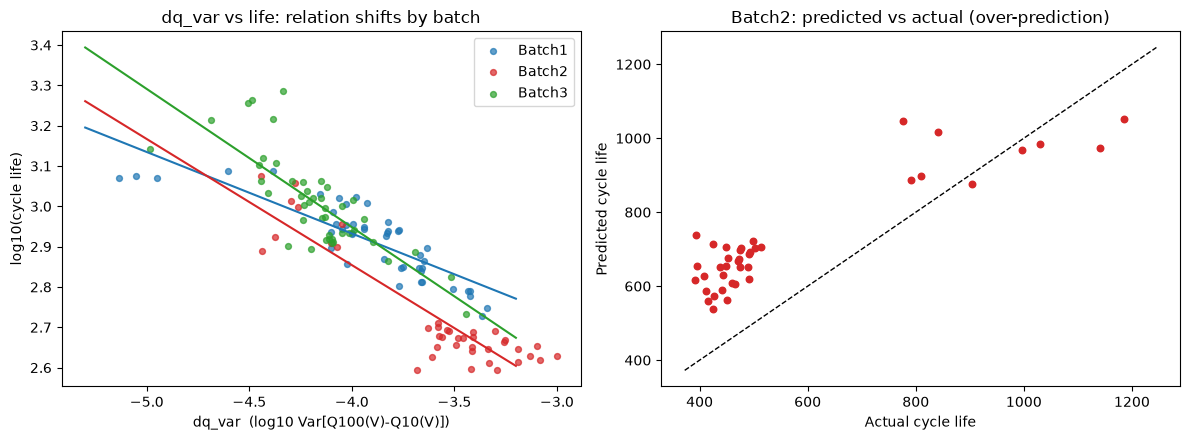

In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
colors = {'Batch1': '#1f77b4', 'Batch2': '#d62728', 'Batch3': '#2ca02c'}
x = np.linspace(-5.3, -3.2, 50)

for name, d in [('Batch1', B1), ('Batch2', B2), ('Batch3', B3)]:
    ax[0].scatter(d.dq_var, d.log_life, s=18, alpha=.7, color=colors[name], label=name)
    m = LinearRegression().fit(d[['dq_var']], d['log_life'])
    ax[0].plot(x, m.predict(pd.DataFrame({'dq_var': x})), color=colors[name], lw=1.5)
ax[0].set_xlabel('dq_var  (log10 Var[Q100(V)-Q10(V)])')
ax[0].set_ylabel('log10(cycle life)')
ax[0].set_title('dq_var vs life: relation shifts by batch')
ax[0].legend()

actual, predicted = B2.cycle_life.values, 10 ** pred_b2
lo, hi = min(actual.min(), predicted.min()) * 0.95, max(actual.max(), predicted.max()) * 1.05
ax[1].scatter(actual, predicted, s=22, color=colors['Batch2'])
ax[1].plot([lo, hi], [lo, hi], 'k--', lw=1)
ax[1].set_xlabel('Actual cycle life')
ax[1].set_ylabel('Predicted cycle life')
ax[1].set_title('Batch2: predicted vs actual (over-prediction)')

plt.tight_layout()
plt.savefig('../results/batch_shift.png', dpi=150)
plt.show()

In [15]:
mask = B2.cycle_life < 600
rho_s, _ = spearmanr(B2.loc[mask, 'dq_var'], B2.loc[mask, 'log_life'])
print(f'Batch2 수명 600 미만 {mask.sum()}셀 안에서 Spearman = {rho_s:.3f}')

Batch2 수명 600 미만 30셀 안에서 Spearman = -0.396
